# Phân Tích vị Trí địa lý

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [7]:
geolocation_data = pd.read_csv(RAW_DIR /"olist_geolocation_dataset.csv")

In [ ]:
# Thông tin tổng quan về các cột
geolocation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [3]:
display(geolocation_data.head())
print(geolocation_data.shape)
geolocation_data.dtypes


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


(1000163, 5)


geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

In [10]:
#  Kiểm tra dữ liệu thiếu và trùng lặp
missing = geolocation_data.isnull().sum()
print("Giá trị thiếu theo cột:\n", missing[missing > 0])
duplicates = geolocation_data.duplicated().sum()
print(f"\nSố lượng bản ghi trùng lặp hoàn toàn: {duplicates}")

Giá trị thiếu theo cột:
 Series([], dtype: int64)

Số lượng bản ghi trùng lặp hoàn toàn: 261831


In [11]:
#  Thống kê các giá trị duy nhất
unique_zip = geolocation_data['geolocation_zip_code_prefix'].nunique()
unique_cities = geolocation_data['geolocation_city'].nunique()
unique_states = geolocation_data['geolocation_state'].nunique()

print(f"Số mã zip prefix duy nhất: {unique_zip}")
print(f"Số thành phố duy nhất: {unique_cities}")
print(f"Số bang duy nhất: {unique_states}")

top_cities = geolocation_data['geolocation_city'].value_counts().head(10)
print("\nTop 10 thành phố xuất hiện nhiều nhất:")
print(top_cities)

Số mã zip prefix duy nhất: 19015
Số thành phố duy nhất: 8011
Số bang duy nhất: 27

Top 10 thành phố xuất hiện nhiều nhất:
geolocation_city
sao paulo                135800
rio de janeiro            62151
belo horizonte            27805
são paulo                 24918
curitiba                  16593
porto alegre              13521
salvador                  11865
guarulhos                 11340
brasilia                  10470
sao bernardo do campo      8112
Name: count, dtype: int64


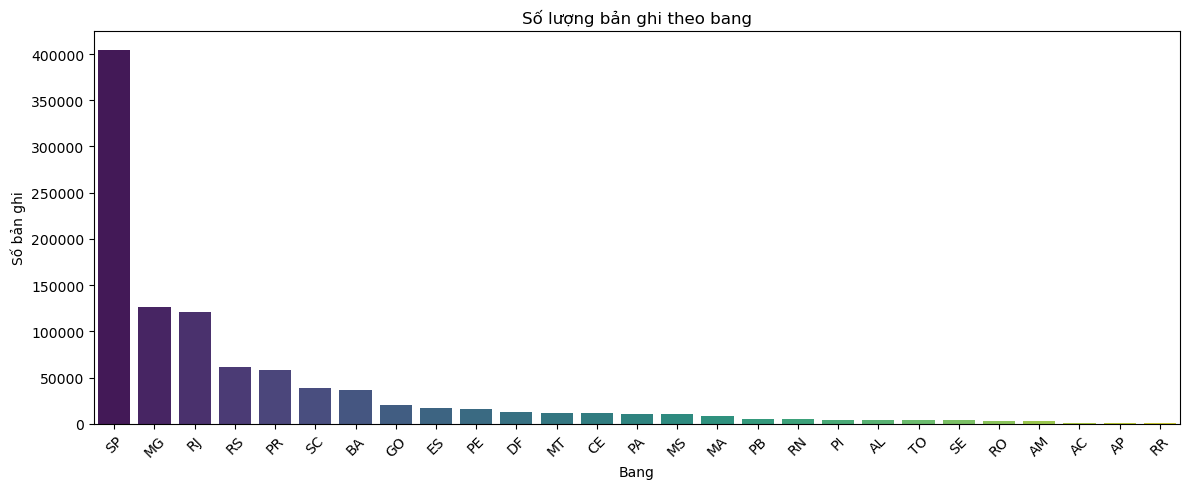

Top 5 bang chiếm tỉ lệ cao nhất:
geolocation_state
SP    40.420212
MG    12.631541
RJ    12.114925
RS     6.184092
PR     5.784957
Name: count, dtype: float64


In [12]:
#  Phân bố theo bang
state_counts = geolocation_data['geolocation_state'].value_counts()
plt.figure(figsize=(12,5))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Số lượng bản ghi theo bang')
plt.xlabel('Bang')
plt.ylabel('Số bản ghi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

state_pct = (state_counts / len(geolocation_data)) * 100
print("Top 5 bang chiếm tỉ lệ cao nhất:")
print(state_pct.head(5))

In [13]:
#  Phân tích mối quan hệ zip code - thành phố
zip_city = geolocation_data.groupby('geolocation_zip_code_prefix')['geolocation_city'].nunique()
multi_city_zips = zip_city[zip_city > 1]
print(f"Số zip code xuất hiện ở nhiều hơn 1 thành phố: {len(multi_city_zips)}")
if len(multi_city_zips) > 0:
    print("Ví dụ:", multi_city_zips.head())

city_zip = geolocation_data.groupby('geolocation_city')['geolocation_zip_code_prefix'].nunique()
print(f"\nThành phố có nhiều zip code nhất: {city_zip.idxmax()} với {city_zip.max()} zip")

Số zip code xuất hiện ở nhiều hơn 1 thành phố: 8556
Ví dụ: geolocation_zip_code_prefix
1001    2
1002    2
1003    2
1004    2
1005    2
Name: geolocation_city, dtype: int64

Thành phố có nhiều zip code nhất: sao paulo với 3171 zip


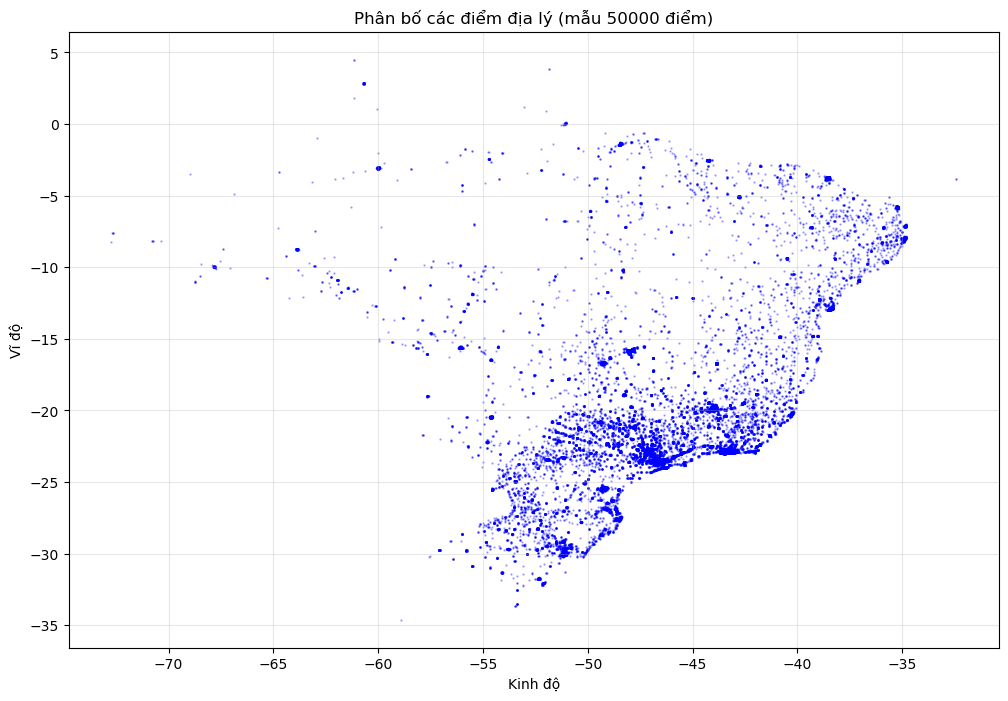

In [14]:
# ## 8. Phân bố không gian (scatter plot)
sample_size = min(50000, len(geolocation_data))
df_sample = geolocation_data.sample(n=sample_size, random_state=42)

plt.figure(figsize=(12,8))
plt.scatter(df_sample['geolocation_lng'], df_sample['geolocation_lat'], 
            s=0.5, alpha=0.3, c='blue')
plt.title(f'Phân bố các điểm địa lý (mẫu {sample_size} điểm)')
plt.xlabel('Kinh độ')
plt.ylabel('Vĩ độ')
plt.grid(alpha=0.3)
plt.show()